# traQmania 02 — Q-learning from scratch

In [notebook 01](01_the_racing_env.ipynb) we saw the racing environment: 4
observation features, 4 discrete actions, progress-based reward. Now we make an
agent *learn* to drive — with a classical neural network so small it will be
directly comparable to a 4-qubit quantum circuit later.

## The 60-second theory

Driving is a **Markov decision process**: at each step the agent sees a state
$s$, picks an action $a$, gets a reward $r$ and a next state $s'$. The
**Q-function** $Q(s, a)$ is the total discounted reward you can still collect
by taking action $a$ in state $s$ and playing well afterwards. The optimal
Q-function satisfies the Bellman equation

$$Q^*(s, a) = \mathbb{E}\left[\, r + \gamma \max_{a'} Q^*(s', a') \,\right],$$

and once you have it, the optimal policy is trivial: pick
$\arg\max_a Q(s, a)$.

**Deep Q-learning (DQN)** approximates $Q$ with a parameterized function and
regresses it onto the right-hand side of the Bellman equation, with three
stabilizing tricks used here:

- **replay buffer** — train on random past transitions, not just the latest ones
- **target network** — a slow-moving copy of the parameters computes the target
  $r + \gamma\, Q_\mathrm{target}(s', a^*)$, with the online network choosing
  $a^*$ (**double DQN**)
- **$\varepsilon$-greedy exploration** — act randomly with probability
  $\varepsilon$, annealed from 1.0 to 0.05

The whole loop is ~200 lines of numpy in `traqmania.agents.training.dqn` — no
deep-learning framework. That matters later: the same loop will train the
quantum circuit unchanged.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import matplotlib.pyplot as plt
import numpy as np

## The classical Q-function

`MLPQFunction` is a single-hidden-layer network: 4 features → 8 tanh units → 4
Q-values, i.e. **76 parameters** in one flat vector. Every Q-function backend
in traQmania implements the same 4-method protocol (`q_values`,
`grad_selected`, `get_params`, `set_params`), which is all the trainer needs.

In [2]:
from traqmania.agents.classical import MLPQFunction

qfunc = MLPQFunction(n_features=4, hidden=8, n_actions=4, seed=0)
print(f"parameters: {qfunc.n_params}")
print("Q-values for one observation:", np.round(qfunc.q_values([[0.5, 1.0, 0.5, 0.3]]), 3))

parameters: 76
Q-values for one observation: [[-0.388 -0.571 -0.268  0.271]]


## Train it

300 episodes on the oval, 8 vectorized cars collecting experience in parallel,
one gradient update per environment decision. On a laptop this takes on the
order of ten seconds. The `CleanLapMonitor` wrapper records the first episode
in which a full lap was driven without leaving the track.

In [3]:
import time

from traqmania.agents.training import DQNTrainer
from traqmania.config import load_config
from traqmania.env.racing_env import RacingEnv
from traqmania.env.track import Track
from traqmania.train_headless import CleanLapMonitor

config = load_config()
training_cfg = dict(config["training"])
training_cfg["seed"] = 0

track = Track.load("oval")
env = RacingEnv(track, config, n_envs=training_cfg["n_parallel_envs"], seed=0)
monitor = CleanLapMonitor(env)
qfunc = MLPQFunction(n_features=env.n_features, hidden=8, n_actions=4, seed=0)
trainer = DQNTrainer(qfunc, monitor, training_cfg, rng=np.random.default_rng(0))

t0 = time.perf_counter()
history = trainer.train(episodes=300)
print(f"trained 300 episodes in {time.perf_counter() - t0:.1f} s")
print(f"first clean lap: episode {monitor.first_clean_episode} "
      f"(after {monitor.first_clean_wall_s:.1f} s of training)")
print(f"best lap during training: {monitor.best_lap_s:.1f} s")

trained 300 episodes in 8.8 s
first clean lap: episode 165 (after 1.1 s of training)
best lap during training: 12.7 s


## The learning curve

Per-episode returns are noisy (spawn jitter, exploration), so we overlay a
rolling mean. Reading the y-axis: one lap of the oval is ~230 units of progress
plus bonuses, so returns in the several hundreds mean multiple laps per
episode.

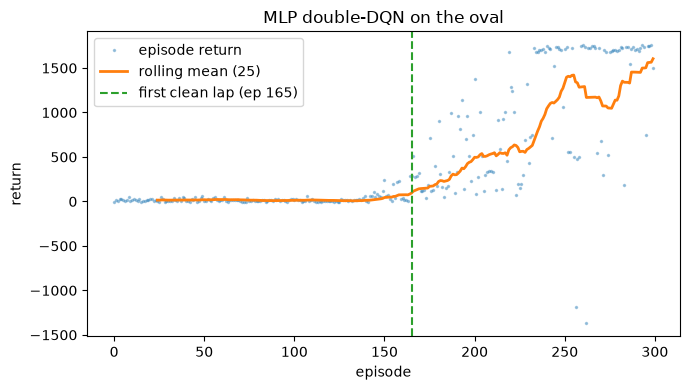

In [4]:
returns = np.array(history["episode_returns"])
window = 25
smooth = np.convolve(returns, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(returns, ".", ms=3, alpha=0.35, label="episode return")
ax.plot(np.arange(window - 1, len(returns)), smooth, lw=2,
        label=f"rolling mean ({window})")
if monitor.first_clean_episode:
    ax.axvline(monitor.first_clean_episode, color="tab:green", ls="--",
               label=f"first clean lap (ep {monitor.first_clean_episode})")
ax.set(xlabel="episode", ylabel="return", title="MLP double-DQN on the oval")
ax.legend()
plt.tight_layout()
plt.show()

## Watch what it learned: greedy rollout

Set $\varepsilon = 0$ and let the trained network drive a fresh car. The
trajectory is colored by speed — look for the learned racing behavior: full
throttle on the straights, slower through the turns.

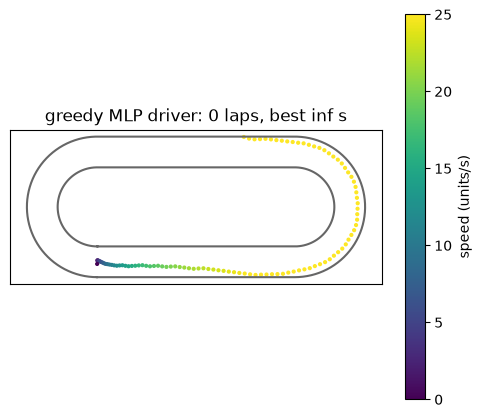

greedy rollout: 0 laps, best lap inf s


In [5]:
def draw_track(ax, track):
    cl, hw = track.centerline, track.half_width
    for sign in (+1.0, -1.0):
        b = cl + sign * hw * track.normals
        b = np.vstack([b, b[:1]])
        ax.plot(b[:, 0], b[:, 1], color="0.4", lw=1.5)
    ax.set_aspect("equal")
    ax.set_xticks([]), ax.set_yticks([])


eval_env = RacingEnv(track, config, n_envs=1, seed=123)
obs = eval_env.reset()
xy, speed, best_lap, laps = [], [], np.inf, 0
for _ in range(400):
    actions = np.argmax(qfunc.q_values(obs), axis=1)  # greedy
    obs, reward, done, info = eval_env.step(actions)
    xy.append(eval_env.state[0, :2].copy())
    speed.append(eval_env.state[0, 3])
    if not np.isnan(info["last_lap_time"][0]):
        best_lap = min(best_lap, info["last_lap_time"][0])
    laps = max(laps, info["lap"][0])
    if done[0]:
        break
xy = np.array(xy)

fig, ax = plt.subplots(figsize=(6, 5))
draw_track(ax, track)
sc = ax.scatter(xy[:, 0], xy[:, 1], c=speed, s=4, cmap="viridis")
fig.colorbar(sc, ax=ax, label="speed (units/s)")
ax.set_title(f"greedy MLP driver: {laps} laps, best {best_lap:.1f} s")
plt.show()
print(f"greedy rollout: {laps} laps, best lap {best_lap:.1f} s")

A 76-parameter network learns to lap the oval in seconds of wall-clock time.

The key design point of traQmania: `DQNTrainer` only ever talks to the
Q-function through `q_values` / `grad_selected` / `get_params` / `set_params`.
Anything implementing those four methods can drive — including a quantum
circuit.

**Next:** [03 — Quantum circuits as Q-functions](03_quantum_circuits_as_q_functions.ipynb)
builds exactly that.